## Load csv file

In [16]:
import pandas as pd
import ast

path = "C:/DataSet/ptb-xl/"

df = pd.read_csv(path + "ptbxl_database.csv", index_col="ecg_id")

# convert string dict to python dict
df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

print(df.head())

        patient_id   age  sex  height  weight  nurse  site     device  \
ecg_id                                                                  
1          15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
2          13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
3          20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   
4          17014.0  24.0    0     NaN    82.0    2.0   0.0  CS-12   E   
5          17448.0  19.0    1     NaN    70.0    2.0   0.0  CS-12   E   

             recording_date                                  report  ...  \
ecg_id                                                               ...   
1       1984-11-09 09:17:34  sinusrhythmus periphere niederspannung  ...   
2       1984-11-14 12:55:37     sinusbradykardie sonst normales ekg  ...   
3       1984-11-15 12:49:10              sinusrhythmus normales ekg  ...   
4       1984-11-15 13:44:57              sinusrhythmus normales ekg  ...   
5       1984-11-17 10:43:15     

## convert web signal to numpy array

In [7]:
import wfdb
import numpy as np

def load_ecg(df, path):
    
    signals = []
    
    for file in df.filename_lr:
        signal, meta = wfdb.rdsamp(path + file)
        signals.append(signal)

    signals = np.array(signals)

    return signals


X = load_ecg(df, path)

print(X.shape)

(21799, 1000, 12)


In [8]:
agg_df = pd.read_csv(path + "scp_statements.csv", index_col=0)

agg_df = agg_df[agg_df.diagnostic == 1]

In [9]:
agg_df.sample()

,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN


In [ ]:
def aggregate_diagnostic(y_dic):
 
    tmp = []

    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)

    return list(set(tmp))

               
df["diagnostic_superclass"] = df.scp_codes.apply(aggregate_diagnostic)

In [11]:
df["diagnostic_superclass"].value_counts()

diagnostic_superclass
[NORM]                 9069
[MI]                   2532
[STTC]                 2400
[CD]                   1708
[CD, MI]               1297
[HYP, STTC]             781
[MI, STTC]              599
[HYP]                   535
[CD, STTC]              471
[]                      411
[NORM, CD]              407
[HYP, MI, STTC]         361
[CD, HYP]               300
[CD, MI, STTC]          223
[CD, HYP, STTC]         211
[HYP, MI]               183
[CD, HYP, MI, STTC]     156
[CD, HYP, MI]           117
[NORM, STTC]             28
[NORM, CD, STTC]          5
[NORM, CD, HYP]           2
[NORM, HYP]               2
[NORM, CD, HYP, MI]       1
Name: count, dtype: int64

In [12]:
test_fold = 10

X_train = X[df.strat_fold != test_fold]
X_test  = X[df.strat_fold == test_fold]

y_train = df[df.strat_fold != test_fold].diagnostic_superclass
y_test  = df[df.strat_fold == test_fold].diagnostic_superclass

In [16]:
np.save("ecg_Clean_data/ecg_X_train.npy", X_train)
np.save("ecg_Clean_data/ecg_X_test.npy", X_test)
np.save("ecg_Clean_data/ecg_y_train.npy", y_train)
np.save("ecg_Clean_data/ecg_y_test.npy", y_test)

In [ ]:
X_train.shape

(19601, 1000, 12)

In [18]:
X_test.shape

(2198, 1000, 12)

In [19]:
y_train.shape

(19601,)

In [20]:
y_train[:2]

ecg_id
1    [NORM]
2    [NORM]
Name: diagnostic_superclass, dtype: object

In [16]:
y_train.isnull().sum()

np.int64(0)

In [ ]:
#### Class	    Full Name	                    Meaning
#### NORM	| Normal ECG	            |No abnormal heart condition detected
#### MI	    | Myocardial                |Infarction	Heart attack / damaged heart muscle
#### STTC	| ST/T Change	            |Abnormal ST segment or T wave (possible ischemia)
#### HYP	| Hypertrophy	            |Thickening/enlargement of heart muscle
#### CD	    | Conduction Disturbance	|Electrical signal conduction problem in heart

In [22]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

y_train = mlb.fit_transform(y_train)
y_test = mlb.transform(y_test)

In [17]:
class_label = ["NORM", "MI","STTC", "HYP","CD"]

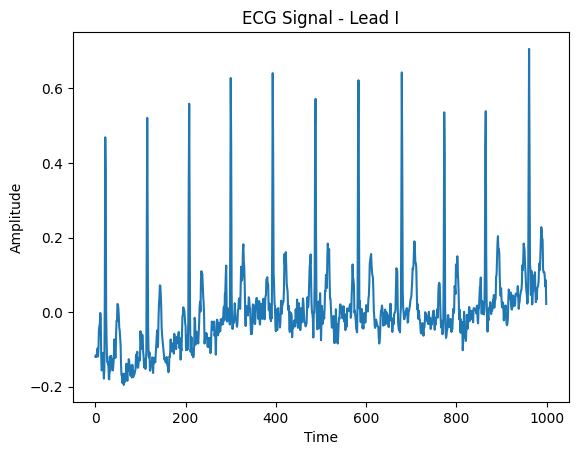

In [19]:
import matplotlib.pyplot as plt

signal = X_train[0]   # first ECG sample

lead1 = signal[:,0]   # Lead I

plt.plot(lead1)
plt.title("ECG Signal - Lead I")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

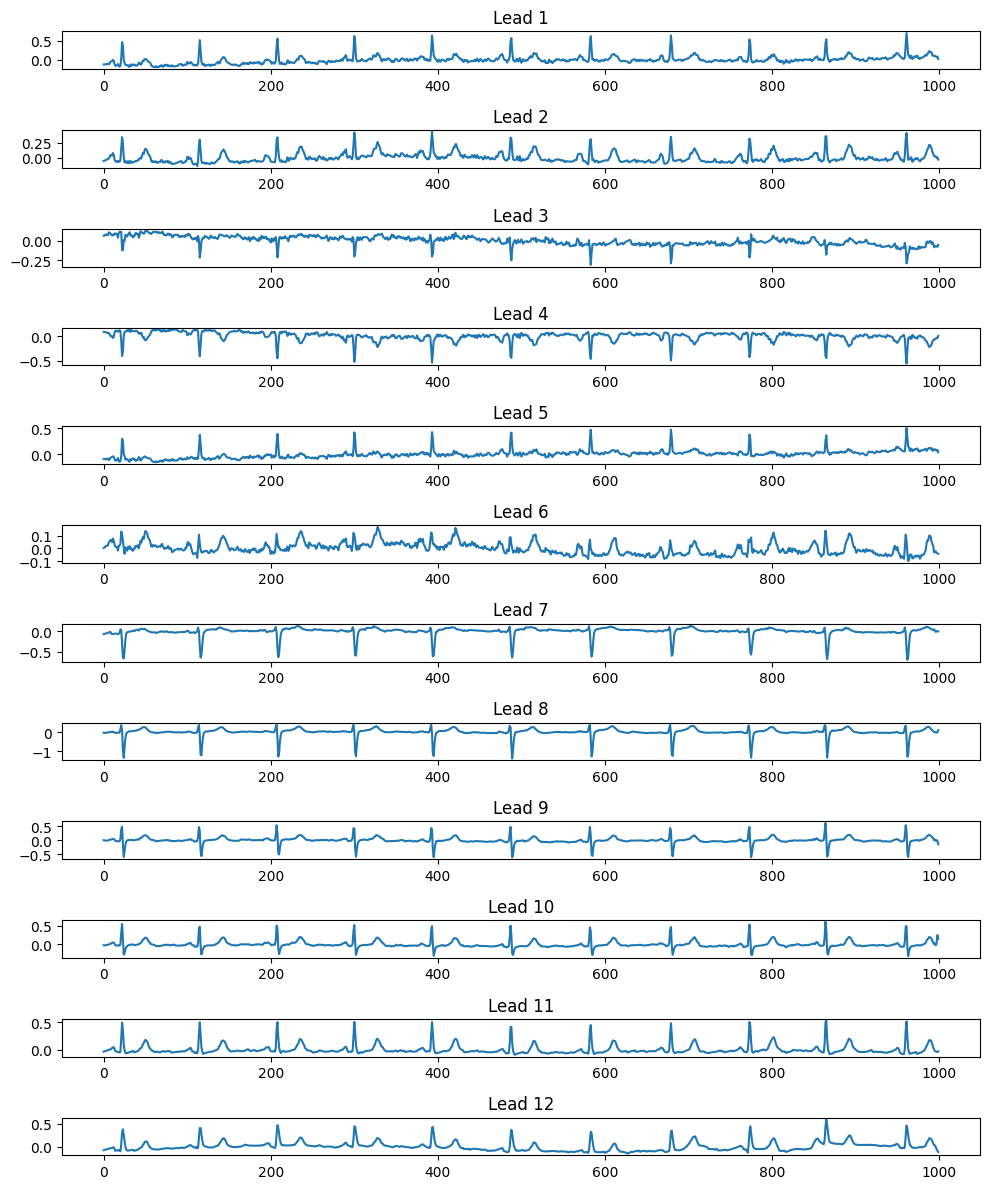

In [20]:
fig, axs = plt.subplots(12,1, figsize=(10,12))

for i in range(12):
    axs[i].plot(signal[:,i])
    axs[i].set_title(f"Lead {i+1}")

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
X_test = np.load("../ecg_Clean_data/ecg_X_test.npy")
X_train = np.load("../ecg_Clean_data/ecg_X_train.npy")
y_test = np.load("../ecg_Clean_data/ecg_y_test.npy", allow_pickle=True)
y_train = np.load("../ecg_Clean_data/ecg_y_train.npy", allow_pickle=True)

In [13]:
X_train.shape

(19601, 1000, 12)

In [14]:
X_test.shape

(2198, 1000, 12)

In [12]:
X_train[:5]

array([[[-1.190e-01, -5.500e-02,  6.400e-02, ..., -2.600e-02,
         -3.900e-02, -7.900e-02],
        [-1.160e-01, -5.100e-02,  6.500e-02, ..., -3.100e-02,
         -3.400e-02, -7.400e-02],
        [-1.200e-01, -4.400e-02,  7.600e-02, ..., -2.800e-02,
         -2.900e-02, -6.900e-02],
        ...,
        [ 6.900e-02,  0.000e+00, -6.900e-02, ...,  2.400e-02,
         -4.100e-02, -5.800e-02],
        [ 8.600e-02,  4.000e-03, -8.100e-02, ...,  2.420e-01,
         -4.600e-02, -9.800e-02],
        [ 2.200e-02, -3.100e-02, -5.400e-02, ...,  1.430e-01,
         -3.500e-02, -1.200e-01]],

       [[ 4.000e-03,  1.380e-01,  1.340e-01, ...,  1.920e-01,
          8.300e-02,  8.800e-02],
        [-2.000e-02,  1.160e-01,  1.360e-01, ...,  1.560e-01,
          5.700e-02,  6.300e-02],
        [-5.300e-02,  9.200e-02,  1.450e-01, ...,  1.070e-01,
          1.300e-02,  2.200e-02],
        ...,
        [ 1.210e-01,  3.980e-01,  2.770e-01, ..., -1.065e+00,
         -4.920e-01, -1.560e-01],
        [-3.

### Apply CNN model in ECG dataset

In [18]:
import tensorflow as tf
from tensorflow import keras


In [24]:
model = keras.Sequential([
    keras.layers.Conv1D(filters=32,kernel_size=5,activation='relu',input_shape=(1000,12)),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(filters=64,kernel_size=5,activation='relu'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(filters=128,kernel_size=3,activation='relu'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(5, activation="sigmoid"),
])

c:\Users\ytsub\Desktop\github\Know_Your_Health_MLModel\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [26]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
490/490 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.5761 - loss: 0.4106 - val_accuracy: 0.6149 - val_loss: 0.3584
Epoch 2/30
490/490 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.6584 - loss: 0.3329 - val_accuracy: 0.6368 - val_loss: 0.3336
Epoch 3/30
490/490 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.6832 - loss: 0.3021 - val_accuracy: 0.6279 - val_loss: 0.3150
Epoch 4/30
490/490 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7003 - loss: 0.2737 - val_accuracy: 0.6672 - val_loss: 0.3120
Epoch 5/30
490/490 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.7260 - loss: 0.2437 - val_accuracy: 0.6560 - val_loss: 0.3100
Epoch 6/30
490/490 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.7474 - loss: 0.2147 - val_accuracy: 0.6480 - val_loss: 0.3358
Epoch 7/30
490/490 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7742 - loss: 0.1801 - val_accuracy: 0.6287 - val_loss: 0.3709
Epoch 8/30
490/490 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7881 - loss: 0.1526 - 

In [28]:
model.evaluate(X_test, y_test)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6374 - loss: 0.9430


[0.9429606199264526, 0.6373976469039917]

In [ ]:
pred = model.predict(X_test)
pred[0]

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


array([3.5687184e-09, 3.9623617e-12, 3.4648822e-17, 9.9480999e-01,
       5.9643133e-07], dtype=float32)

In [33]:
y_test[0]

array([0, 0, 0, 1, 0])